# A6: Machine Learning Algorithms from Scratch

**Assignment:** Implement K-Means and Linear Discriminant Analysis (LDA) without using their built-in machine-learning implementations. Show initialization, distance/assignment/centroid updates and convergence for K-Means; show class means, within/between-class scatter, eigendecomposition and projection for LDA; visualize both results.

**Answer:** The cells use reproducible synthetic datasets because the assignment does not specify one. NumPy implements both algorithms; Matplotlib is used only for visualization.

Centroids:
 [[-0.10424443  2.92658962]
 [ 2.89070642 -1.19245204]
 [-3.08173711 -1.03330677]]
Within-cluster SSE: 110.43928895883232


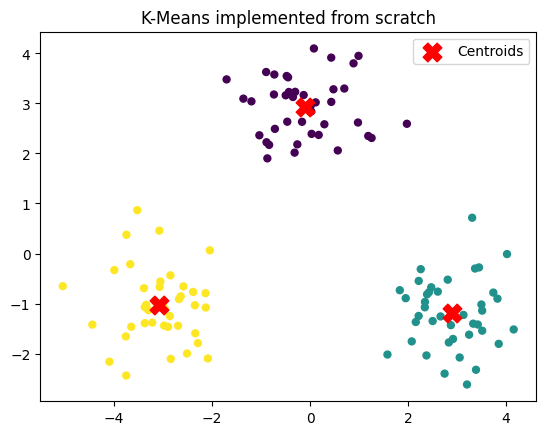

In [1]:
import numpy as np

def kmeans(X, k, max_iter=100, tol=1e-6, random_state=42):
    """K-Means using NumPy only; returns labels, centroids, and within-cluster SSE."""
    X = np.asarray(X, dtype=float)
    if not 1 <= k <= len(X):
        raise ValueError("k must be between 1 and the number of samples")
    rng = np.random.RandomState(random_state)
    centroids = X[rng.choice(len(X), size=k, replace=False)].copy()
    labels = np.full(len(X), -1)

    for _ in range(max_iter):
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        new_labels = distances.argmin(axis=1)
        updated_centroids = centroids.copy()
        for cluster_id in range(k):
            points = X[new_labels == cluster_id]
            if len(points):
                updated_centroids[cluster_id] = points.mean(axis=0)
        converged = np.array_equal(new_labels, labels) or np.linalg.norm(updated_centroids - centroids) <= tol
        labels, centroids = new_labels, updated_centroids
        if converged:
            break

    sse = sum(((X[labels == j] - centroids[j]) ** 2).sum() for j in range(k))
    return labels, centroids, sse

# A reproducible three-cluster dataset; no labeled training targets are used.
rng = np.random.RandomState(12)
X_kmeans = np.vstack([
    rng.normal(loc=(-3, -1), scale=0.65, size=(40, 2)),
    rng.normal(loc=(0, 3), scale=0.65, size=(40, 2)),
    rng.normal(loc=(3, -1), scale=0.65, size=(40, 2)),
])
kmeans_labels, kmeans_centroids, kmeans_sse = kmeans(X_kmeans, k=3)
print("Centroids:\n", kmeans_centroids)
print("Within-cluster SSE:", kmeans_sse)
try:
    import matplotlib.pyplot as plt
    plt.scatter(X_kmeans[:, 0], X_kmeans[:, 1], c=kmeans_labels, cmap="viridis", s=25)
    plt.scatter(kmeans_centroids[:, 0], kmeans_centroids[:, 1], c="red", marker="X", s=180, label="Centroids")
    plt.title("K-Means implemented from scratch")
    plt.legend()
    plt.show()
except ImportError:
    print("Install matplotlib to display the clustering visualization.")

Within-class scatter S_W:
 [[44.59699079  1.63960207]
 [ 1.63960207 52.44857174]]
Between-class scatter S_B:
 [[289.67358161 146.17196251]
 [146.17196251  73.75972122]]
Sorted eigenvalues: [7.70561805e+00 2.22044605e-16]
Selected discriminant vector:
 [[0.92713315]
 [0.37473207]]
Reduced data shape: (80, 1)


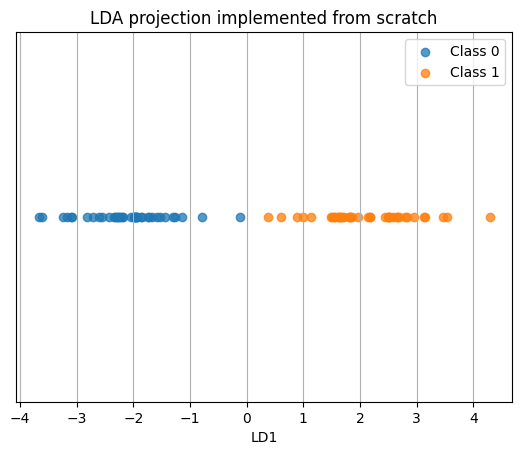

In [2]:
import numpy as np

def lda_project(X, y, n_components=None, ridge=1e-6):
    """Fisher LDA projection from scratch using NumPy; returns projected data and scatter/eigen details."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    classes = np.unique(y)
    if len(classes) < 2:
        raise ValueError("LDA requires at least two classes")
    overall_mean = X.mean(axis=0)
    n_features = X.shape[1]
    within_scatter = np.zeros((n_features, n_features))
    between_scatter = np.zeros((n_features, n_features))
    class_means = {}

    for label in classes:
        class_points = X[y == label]
        class_mean = class_points.mean(axis=0)
        class_means[label] = class_mean
        centered = class_points - class_mean
        within_scatter += centered.T @ centered
        mean_delta = (class_mean - overall_mean).reshape(-1, 1)
        between_scatter += len(class_points) * (mean_delta @ mean_delta.T)

    regularized_within = within_scatter + ridge * np.eye(n_features)
    matrix = np.linalg.solve(regularized_within, between_scatter)
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)
    order = np.argsort(eigenvalues)[::-1]
    max_components = min(n_features, len(classes) - 1)
    if n_components is None:
        n_components = max_components
    if not 1 <= n_components <= max_components:
        raise ValueError("n_components must be between 1 and C - 1")

    directions = eigenvectors[:, order[:n_components]]
    projected = (X - overall_mean) @ directions
    return projected, directions, class_means, overall_mean, within_scatter, between_scatter, eigenvalues[order]

rng = np.random.RandomState(21)
X_lda = np.vstack([
    rng.normal(loc=(-2, -1), scale=0.75, size=(40, 2)),
    rng.normal(loc=(2, 1), scale=0.75, size=(40, 2)),
])
y_lda = np.array([0] * 40 + [1] * 40)
projected, lda_directions, class_means, overall_mean, S_W, S_B, eigenvalues = lda_project(X_lda, y_lda, n_components=1)
print("Within-class scatter S_W:\n", S_W)
print("Between-class scatter S_B:\n", S_B)
print("Sorted eigenvalues:", eigenvalues)
print("Selected discriminant vector:\n", lda_directions)
print("Reduced data shape:", projected.shape)
try:
    import matplotlib.pyplot as plt
    plt.scatter(projected[y_lda == 0, 0], np.zeros((y_lda == 0).sum()), label="Class 0", alpha=0.75)
    plt.scatter(projected[y_lda == 1, 0], np.zeros((y_lda == 1).sum()), label="Class 1", alpha=0.75)
    plt.xlabel("LD1")
    plt.yticks([])
    plt.title("LDA projection implemented from scratch")
    plt.legend()
    plt.grid(True, axis="x")
    plt.show()
except ImportError:
    print("Install matplotlib to display the LDA visualization.")